<a href="https://colab.research.google.com/github/Raju-24-25/Deep-Learning-Handsons/blob/main/Gradient_Descent_Algorithm_Demonstration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### GRADIENT DESCENT ALGORITHM DEMONSTRATION

Importing Necessery Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Data Generation and Setup
# -------------------------------

`Simple Linear Regression if it is a 2D` -- Simply one input and one output

In [2]:
def generate_data (n_samples = 100, noise = 0.1, seed = 42):
  '''
  Generate random Sample (synthetic) Linear Data
  '''
  np.random.seed(seed) # to ensure the reproducibility of the same random data --> to fix the random numbers generated
  X = 2*np.random.randn(n_samples, 1) #generates random numbers from standard normal distribution
  y = 4 + 3*X + noise * np.random.randn(n_samples,1) # creates a random distribution around a line having some noise added to it

  return X, y

In [3]:
### Let us generate a sample data
X, y = generate_data(n_samples=100, noise=2)

In [4]:
print("Shape for X, y:", X.shape, y.shape)

Shape for X, y: (100, 1) (100, 1)


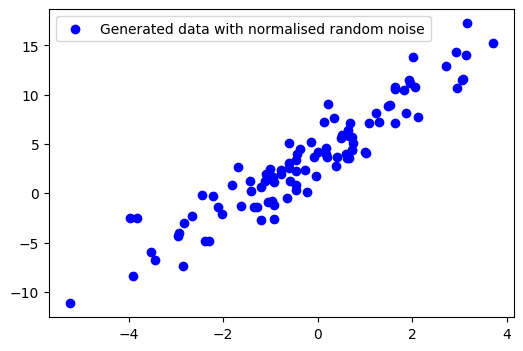

In [43]:
### Let us plot the generated data distribution
plt.figure(figsize=(6,4))
plt.scatter(X, y, color = 'blue', label = 'Generated data with normalised random noise')
plt.legend()
plt.show()

# Adding a `Unit Bias` term to X

In [10]:
# Numbers of rows in the data
m = len(y)
print('Number of Rows : ', m)

Number of Rows :  100


In [12]:
# Let us add the Unit Bias term
X_b = np.c_[np.ones((m,1)), X] ### adding a constant column having entries 1

In [13]:
X[:10]

array([[ 0.99342831],
       [-0.2765286 ],
       [ 1.29537708],
       [ 3.04605971],
       [-0.46830675],
       [-0.46827391],
       [ 3.15842563],
       [ 1.53486946],
       [-0.93894877],
       [ 1.08512009]])

In [14]:
X_b[:10]

array([[ 1.        ,  0.99342831],
       [ 1.        , -0.2765286 ],
       [ 1.        ,  1.29537708],
       [ 1.        ,  3.04605971],
       [ 1.        , -0.46830675],
       [ 1.        , -0.46827391],
       [ 1.        ,  3.15842563],
       [ 1.        ,  1.53486946],
       [ 1.        , -0.93894877],
       [ 1.        ,  1.08512009]])

# Define the `Cost Function`

- For Linear Regression example, we are going to use `Mean Squared Error (MSE)`

In [28]:
def compute_cost (X, y, theta):
  '''
  Compute the mean squared error cost function
  '''
  m = len(y)
  return np.sum((X.dot(theta) - y)**2)/(2*m)

## Writing `Batch Gradient Function`

In [36]:
def bgd (X, y, theta, learning_rate = 0.01, epochs = 100):
  m = len( y ) #no. of rows/training examples
  ### Empty arrays to track cost and theta history
  cost_history = np.zeros(epochs) # 1D array to store the cost after each epoch
  theta_history = np.zeros((epochs, theta.shape[0])) # 2D array to store the parameter values

  for epoch in range(epochs):
    # Compute the Gradient
    gradients = (1/m)*(X.T.dot(X.dot(theta) - y))

    # Update the parameters
    theta = theta - (learning_rate * gradients)

    # Compute the Cost
    cost = compute_cost(X, y, theta)

    # Store History
    cost_history[epoch] = cost
    theta_history[epoch, : ] = theta.T

  return theta, cost_history, theta_history

# Run the `BGD` Algorithm



In [37]:
### Initialize the theta values - weight & bias randomly
np.random.seed(30)
theta = np.random.randn(2,1)
print(theta)

[[-1.26405266]
 [ 1.52790535]]


In [38]:
theta_bgd, cost_history_bgd, theta_history_bgd = bgd(X_b, y, theta, learning_rate=0.1, epochs=100)

In [39]:
cost_history_bgd

array([13.84405091, 11.39069705,  9.50574584,  8.02181568,  6.83676914,
        5.88267047,  5.11100354,  4.48530827,  3.97726577,  3.56443778,
        3.22883908,  2.95595942,  2.7340495 ,  2.55357654,  2.40679752,
        2.28741939,  2.19032581,  2.11135641,  2.04712777,  1.99488822,
        1.95239981,  1.91784235,  1.88973543,  1.86687497,  1.84828168,
        1.83315902,  1.82085917,  1.81085523,  1.80271863,  1.79610082,
        1.79071829,  1.78634047,  1.78277982,  1.7798838 ,  1.77752836,
        1.77561258,  1.77405441,  1.77278708,  1.77175632,  1.77091796,
        1.77023609,  1.7696815 ,  1.76923042,  1.76886355,  1.76856516,
        1.76832246,  1.76812507,  1.76796452,  1.76783394,  1.76772773,
        1.76764135,  1.7675711 ,  1.76751395,  1.76746748,  1.76742968,
        1.76739893,  1.76737392,  1.76735359,  1.76733704,  1.76732359,
        1.76731265,  1.76730375,  1.76729651,  1.76729062,  1.76728583,
        1.76728194,  1.76727877,  1.76727619,  1.7672741 ,  1.76

In [40]:
theta_history_bgd

array([[-0.76376086,  1.85800835],
       [-0.30664223,  2.08926354],
       [ 0.10956755,  2.25348522],
       [ 0.48756712,  2.37200664],
       [ 0.83022834,  2.45915744],
       [ 1.1404335 ,  2.52458491],
       [ 1.42097703,  2.5748037 ],
       [ 1.67450921,  2.61423066],
       [ 1.90350705,  2.64587603],
       [ 2.11026235,  2.67180537],
       [ 2.29688066,  2.69344827],
       [ 2.46528665,  2.71180497],
       [ 2.61723329,  2.72758471],
       [ 2.754313  ,  2.7412984 ],
       [ 2.87796957,  2.75332097],
       [ 2.98951018,  2.76393326],
       [ 3.09011713,  2.77335033],
       [ 3.18085898,  2.78174061],
       [ 3.26270091,  2.78923901],
       [ 3.33651437,  2.79595582],
       [ 3.403086  ,  2.80198294],
       [ 3.46312564,  2.80739819],
       [ 3.51727379,  2.8122684 ],
       [ 3.56610827,  2.81665156],
       [ 3.61015034,  2.8205985 ],
       [ 3.64987018,  2.82415403],
       [ 3.68569188,  2.82735791],
       [ 3.71799796,  2.83024554],
       [ 3.7471334 ,

# Plotting the `Cost Function vs Epoch`

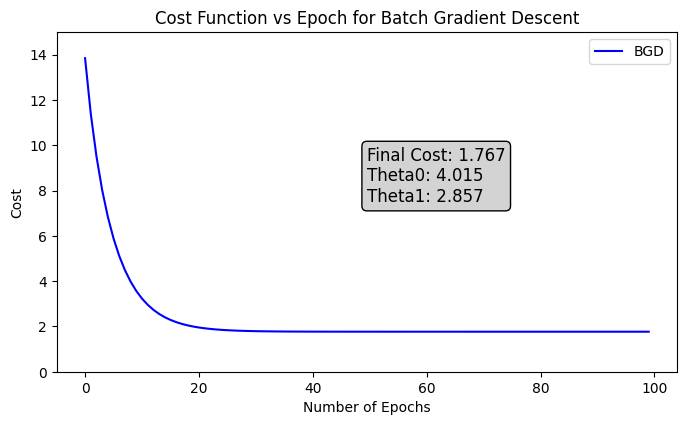

In [41]:
plt.figure(figsize=(8,15))  # The Canvas is ready

# Plotting for BGD
plt.subplot(3, 1, 1)
plt.plot(range(len(cost_history_bgd)), cost_history_bgd, label = 'BGD', color= 'blue')
plt.title('Cost Function vs Epoch for Batch Gradient Descent')
plt.xlabel('Number of Epochs')
plt.ylabel('Cost')
plt.ylim(0,15)
plt.legend()

plt.annotate(f'Final Cost: {cost_history_bgd[-1]:.3f}\nTheta0: {theta_bgd[0][0]:.3f}\nTheta1: {theta_bgd[1][0]:.3f}',
             xy=(0.5, 0.5), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='lightgray'), fontsize=12)

plt.show()

### Let us plot the `best fit line` coming out of `BGD`

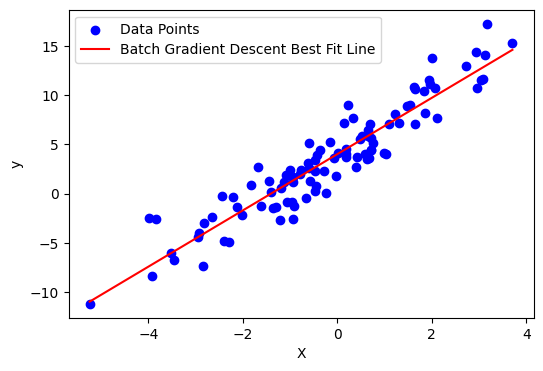

In [42]:
# Create a range of values for plotting the best fit line
x_plot = np.linspace(X.min(), X.max(),100).reshape(100,1)
x_plot_b = np.c_[np.ones((100,1)), x_plot]

# Plot the best-fit line for BGD on top of the data distribution
plt.figure(figsize = (6,4))
plt.scatter(X,y, color='blue', label='Data Points')
plt.plot(x_plot, x_plot_b.dot(theta_bgd), color = 'red', label = 'Batch Gradient Descent Best Fit Line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()